# REZ annual wind-drought time series: ERA5 and BARRA-RE2 ensemble spaghetti plot

This notebook makes a proper ensemble-style comparison:

- **All 22 BARRA-RE2 ensemble members** are plotted as thin light-grey background lines.
- **BARRA-RE2 ensemble mean** is plotted on top as a thick highlighted line.
- **ERA5** is plotted on top as the observational/reanalysis reference line.
- BARRA-RE2 is first moved onto the **ERA5/REZ grid** before REZ statistics are calculated, so the comparison is not biased by BARRA's higher native resolution.

Main outputs:

1. Mean annual wind-drought days across all REZ cells, zeros included.
2. Mean annual wind-drought days only across affected REZ cells.
3. BARRA-RE2 minus ERA5 annual difference, with all BARRA members in grey.
4. CSV tables for ERA5, all BARRA members, BARRA ensemble mean, and comparison metrics.


In [1]:
import os
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


In [3]:
# =====================
# Paths and settings
# =====================
# ERA5 yearly binary wind-drought masks
wd_dir_era5 = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

# BARRA-RE2 yearly binary wind-drought masks, with realization dimension
wd_dir_barra = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"

# REZ mask on ERA5 grid
rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

# Output folder
output_dir = (
    "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/"
    "frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid"
)
os.makedirs(output_dir, exist_ok=True)

start_year = 1990
end_year = 2024

# If the final year is incomplete in your files, set this to True.
DROP_FINAL_YEAR = False

print("ERA5 directory:", wd_dir_era5)
print("BARRA-RE2 directory:", wd_dir_barra)
print("REZ mask:", rez_file)
print("Output directory:", output_dir)


ERA5 directory: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5
BARRA-RE2 directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly
REZ mask: /g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc
Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid


In [4]:
# =====================
# Load REZ mask on ERA5 grid
# =====================
rez_ds = xr.open_dataset(rez_file, engine="netcdf4")

if "rez_mask" in rez_ds.data_vars:
    rez = rez_ds["rez_mask"].squeeze()
else:
    rez = rez_ds[list(rez_ds.data_vars)[0]].squeeze()

# Standardise coordinate names to latitude/longitude
rename_rez = {}
if "lon" in rez.dims or "lon" in rez.coords:
    rename_rez["lon"] = "longitude"
if "lat" in rez.dims or "lat" in rez.coords:
    rename_rez["lat"] = "latitude"
if len(rename_rez) > 0:
    rez = rez.rename(rename_rez)

# Remove singleton non-spatial dimensions if present
for d in list(rez.dims):
    if d not in ["latitude", "longitude"]:
        if rez.sizes[d] == 1:
            rez = rez.isel({d: 0}, drop=True)
        else:
            raise ValueError(f"Unexpected REZ mask dimension: {d}")

# Sort for safe interpolation
rez = rez.sortby("latitude").sortby("longitude")

# Valid REZ cells
rez_valid = np.isfinite(rez)

# ERA5 target grid for BARRA comparison
rez_lat = rez["latitude"]
rez_lon = rez["longitude"]

print("REZ dims :", rez.dims)
print("REZ shape:", rez.shape)
print("Number of REZ cells on ERA5 grid:", int(rez_valid.sum().values))


REZ dims : ('latitude', 'longitude')
REZ shape: (139, 178)
Number of REZ cells on ERA5 grid: 1269


In [5]:
# =====================
# Helper functions
# =====================
def year_from_filename(fp):
    return int(os.path.basename(fp).split("_")[-1].split(".")[0])


def get_year_files(input_dir, pattern, start_year, end_year):
    files = sorted(glob(os.path.join(input_dir, pattern)))
    out = []
    for fp in files:
        yr = year_from_filename(fp)
        if start_year <= yr <= end_year:
            out.append(fp)
    if len(out) == 0:
        raise FileNotFoundError(f"No files found in {input_dir} for {start_year}-{end_year}")
    return out


def get_var_name(ds):
    if "wind_drought" in ds.data_vars:
        return "wind_drought"
    return list(ds.data_vars)[0]


def standardise_lat_lon(da):
    # Rename lon/lat to longitude/latitude and sort spatial coordinates.
    rename = {}
    if "lon" in da.dims or "lon" in da.coords:
        rename["lon"] = "longitude"
    if "lat" in da.dims or "lat" in da.coords:
        rename["lat"] = "latitude"
    if len(rename) > 0:
        da = da.rename(rename)

    if "latitude" in da.coords:
        da = da.sortby("latitude")
    if "longitude" in da.coords:
        da = da.sortby("longitude")

    return da


def coord_resolution(coord):
    vals = np.asarray(coord.values)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    diffs = np.abs(np.diff(vals))
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        return np.nan
    return float(np.median(diffs))


def coarsen_barra_to_era5_grid(da, target_lat, target_lon):
    # Put BARRA annual drought days onto the ERA5/REZ grid.
    # 1. Estimate BARRA and ERA5 grid spacing.
    # 2. Coarsen BARRA by spatial averaging to roughly ERA5 scale.
    # 3. Interpolate the coarsened BARRA field exactly onto the ERA5/REZ grid.
    da = standardise_lat_lon(da)

    barra_lat_res = coord_resolution(da["latitude"])
    barra_lon_res = coord_resolution(da["longitude"])
    era5_lat_res = coord_resolution(target_lat)
    era5_lon_res = coord_resolution(target_lon)

    lat_factor = max(1, int(round(era5_lat_res / barra_lat_res)))
    lon_factor = max(1, int(round(era5_lon_res / barra_lon_res)))

    print(
        f"BARRA native spacing approx lat={barra_lat_res:.4f}, lon={barra_lon_res:.4f}; "
        f"ERA5 spacing approx lat={era5_lat_res:.4f}, lon={era5_lon_res:.4f}; "
        f"coarsen factors lat={lat_factor}, lon={lon_factor}"
    )

    da_coarse = da.coarsen(
        latitude=lat_factor,
        longitude=lon_factor,
        boundary="trim"
    ).mean(skipna=True)

    # Linear interpolation gives smoother common-grid comparison.
    # Nearest is used only to fill edge NaNs.
    da_linear = da_coarse.interp(
        latitude=target_lat,
        longitude=target_lon,
        method="linear"
    )

    da_nearest = da_coarse.interp(
        latitude=target_lat,
        longitude=target_lon,
        method="nearest"
    )

    da_on_era5 = da_linear.fillna(da_nearest)
    return da_on_era5


def compute_rez_stats_from_annual_days(drought_days, rez_valid_da):
    # drought_days: DataArray with annual drought days per grid cell, dimensions latitude, longitude
    # rez_valid_da: boolean DataArray on same grid, dimensions latitude, longitude
    drought_days_rez = drought_days.where(rez_valid_da)

    all_vals = drought_days_rez.values
    all_vals = all_vals[np.isfinite(all_vals)]

    if all_vals.size == 0:
        return np.nan, np.nan, np.nan, np.nan, 0, 0

    affected_vals = all_vals[all_vals > 0]

    mean_all = float(np.mean(all_vals))
    total_days = float(np.sum(all_vals))
    n_rez_cells = int(all_vals.size)
    n_affected = int(affected_vals.size)

    if affected_vals.size == 0:
        mean_affected = np.nan
        median_affected = np.nan
    else:
        mean_affected = float(np.mean(affected_vals))
        median_affected = float(np.median(affected_vals))

    return mean_all, mean_affected, median_affected, total_days, n_rez_cells, n_affected


def build_stats_row(year, source, drought_days, rez_valid_da, realization=""):
    mean_all, mean_aff, med_aff, total_days, n_rez, n_aff = compute_rez_stats_from_annual_days(
        drought_days,
        rez_valid_da
    )

    return {
        "year": int(year),
        "source": source,
        "realization": realization,
        "mean_annual_drought_days_all_rez_cells": mean_all,
        "mean_annual_drought_days_affected_cells": mean_aff,
        "median_annual_drought_days_affected_cells": med_aff,
        "total_rez_drought_cell_days": total_days,
        "n_rez_cells": n_rez,
        "n_affected_cells": n_aff,
        "affected_cell_fraction": n_aff / n_rez if n_rez > 0 else np.nan,
    }


In [6]:
# =====================
# Find ERA5 and BARRA files
# =====================
files_era5 = get_year_files(
    wd_dir_era5,
    "wind_drought_P20_3day_*.nc",
    start_year,
    end_year
)

files_barra = get_year_files(
    wd_dir_barra,
    "wind_drought_P20_3day_*.nc",
    start_year,
    end_year
)

if DROP_FINAL_YEAR:
    files_era5 = files_era5[:-1]
    files_barra = files_barra[:-1]

print(f"ERA5 files found : {len(files_era5)}")
print("ERA5 first:", files_era5[0])
print("ERA5 last :", files_era5[-1])

print(f"BARRA files found: {len(files_barra)}")
print("BARRA first:", files_barra[0])
print("BARRA last :", files_barra[-1])


ERA5 files found : 35
ERA5 first: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
ERA5 last : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2024.nc
BARRA files found: 35
BARRA first: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
BARRA last : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2024.nc


In [7]:
# =====================
# ERA5 annual REZ statistics
# =====================
rows_era5 = []

for fp in files_era5:
    year = year_from_filename(fp)
    print(f"Processing ERA5 {year} ...", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[get_var_name(ds)]
    wd = standardise_lat_lon(wd)

    # Match REZ grid exactly if possible, otherwise interpolate
    try:
        wd = wd.sel(latitude=rez_lat, longitude=rez_lon)
    except Exception:
        wd = wd.interp(latitude=rez_lat, longitude=rez_lon, method="nearest")

    drought_days = wd.sum(dim="time", skipna=True).astype("float32")
    drought_days = drought_days.transpose("latitude", "longitude").load()

    rows_era5.append(
        build_stats_row(year, "ERA5", drought_days, rez_valid, realization="ERA5")
    )

    ds.close()
    del wd, drought_days


df_era5 = pd.DataFrame(rows_era5).sort_values("year").reset_index(drop=True)
df_era5.head()


Processing ERA5 1990 ...
Processing ERA5 1991 ...
Processing ERA5 1992 ...
Processing ERA5 1993 ...
Processing ERA5 1994 ...
Processing ERA5 1995 ...
Processing ERA5 1996 ...
Processing ERA5 1997 ...
Processing ERA5 1998 ...
Processing ERA5 1999 ...
Processing ERA5 2000 ...
Processing ERA5 2001 ...
Processing ERA5 2002 ...
Processing ERA5 2003 ...
Processing ERA5 2004 ...
Processing ERA5 2005 ...
Processing ERA5 2006 ...
Processing ERA5 2007 ...
Processing ERA5 2008 ...
Processing ERA5 2009 ...
Processing ERA5 2010 ...
Processing ERA5 2011 ...
Processing ERA5 2012 ...
Processing ERA5 2013 ...
Processing ERA5 2014 ...
Processing ERA5 2015 ...
Processing ERA5 2016 ...
Processing ERA5 2017 ...
Processing ERA5 2018 ...
Processing ERA5 2019 ...
Processing ERA5 2020 ...
Processing ERA5 2021 ...
Processing ERA5 2022 ...
Processing ERA5 2023 ...
Processing ERA5 2024 ...


,year,source,realization,mean_annual_drought_days_all_rez_cells,mean_annual_drought_days_affected_cells,median_annual_drought_days_affected_cells,total_rez_drought_cell_days,n_rez_cells,n_affected_cells,affected_cell_fraction
0,1990,ERA5,ERA5,18.085106,18.127962,15.5,22950.0,1269,1266,0.997636
1,1991,ERA5,ERA5,26.051222,26.051222,22.0,33059.0,1269,1269,1.000000
2,1992,ERA5,ERA5,29.823483,29.823483,26.0,37846.0,1269,1269,1.000000
3,1993,ERA5,ERA5,22.638298,22.818110,21.0,28728.0,1269,1259,0.992120
4,1994,ERA5,ERA5,22.873917,22.873917,21.0,29027.0,1269,1269,1.000000


In [8]:
# =====================
# BARRA-RE2 annual REZ statistics for EACH realization
# BARRA is coarsened/interpolated to the ERA5/REZ grid before statistics.
# =====================
rows_barra_members = []
realization_labels = None

for fp in files_barra:
    year = year_from_filename(fp)
    print(f"Processing BARRA-RE2 {year} ...", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[get_var_name(ds)]
    wd = standardise_lat_lon(wd)

    if "realization" not in wd.dims:
        raise ValueError("BARRA file does not contain a realization dimension.")

    # Annual drought days for every realization on the native BARRA grid
    days_native = wd.sum(dim="time", skipna=True).astype("float32")
    days_native = days_native.transpose("realization", "latitude", "longitude")

    if realization_labels is None:
        if "realization" in days_native.coords:
            realization_labels = [str(v) for v in days_native["realization"].values]
        else:
            realization_labels = [str(i) for i in range(days_native.sizes["realization"])]
        print("BARRA realizations:", realization_labels)

    # Coarsen/interpolate all realizations to ERA5/REZ grid together
    days_era5_grid = coarsen_barra_to_era5_grid(days_native, rez_lat, rez_lon)
    days_era5_grid = days_era5_grid.transpose("realization", "latitude", "longitude").load()

    # Compute REZ stats separately for every realization
    for i, label in enumerate(realization_labels):
        drought_days_i = days_era5_grid.isel(realization=i).transpose("latitude", "longitude")
        rows_barra_members.append(
            build_stats_row(
                year,
                f"BARRA-RE2 r{label}",
                drought_days_i,
                rez_valid,
                realization=label
            )
        )

    ds.close()
    del wd, days_native, days_era5_grid


df_barra_members = pd.DataFrame(rows_barra_members).sort_values(["realization", "year"]).reset_index(drop=True)
print("BARRA member rows:", len(df_barra_members))
df_barra_members.head()


Processing BARRA-RE2 1990 ...
BARRA realizations: ['000_0', '000_1', '001_0', '001_1', '002_0', '002_1', '003_0', '003_1', '004_0', '004_1', '005_0', '005_1', '006_0', '006_1', '007_0', '007_1', '008_0', '008_1', '009_0', '009_1', 'ctl_0', 'ctl_1']
BARRA native spacing approx lat=0.2200, lon=0.2200; ERA5 spacing approx lat=0.2500, lon=0.2500; coarsen factors lat=1, lon=1
Processing BARRA-RE2 1991 ...
BARRA native spacing approx lat=0.2200, lon=0.2200; ERA5 spacing approx lat=0.2500, lon=0.2500; coarsen factors lat=1, lon=1
Processing BARRA-RE2 1992 ...
BARRA native spacing approx lat=0.2200, lon=0.2200; ERA5 spacing approx lat=0.2500, lon=0.2500; coarsen factors lat=1, lon=1
Processing BARRA-RE2 1993 ...
BARRA native spacing approx lat=0.2200, lon=0.2200; ERA5 spacing approx lat=0.2500, lon=0.2500; coarsen factors lat=1, lon=1
Processing BARRA-RE2 1994 ...
BARRA native spacing approx lat=0.2200, lon=0.2200; ERA5 spacing approx lat=0.2500, lon=0.2500; coarsen factors lat=1, lon=1
Proces

,year,source,realization,mean_annual_drought_days_all_rez_cells,mean_annual_drought_days_affected_cells,median_annual_drought_days_affected_cells,total_rez_drought_cell_days,n_rez_cells,n_affected_cells,affected_cell_fraction
0,1990,BARRA-RE2 r000_0,000_0,20.742820,20.742820,18.497934,26322.638430,1269,1269,1.0
1,1991,BARRA-RE2 r000_0,000_0,26.598907,26.598907,23.000000,33754.012397,1269,1269,1.0
2,1992,BARRA-RE2 r000_0,000_0,30.478295,30.478295,26.462810,38676.956612,1269,1269,1.0
3,1993,BARRA-RE2 r000_0,000_0,23.206800,23.206800,22.446281,29449.429752,1269,1269,1.0
4,1994,BARRA-RE2 r000_0,000_0,23.668720,23.668720,22.661157,30035.605372,1269,1269,1.0


In [9]:
# =====================
# BARRA-RE2 ensemble mean time series from member statistics
# =====================
metric_cols = [
    "mean_annual_drought_days_all_rez_cells",
    "mean_annual_drought_days_affected_cells",
    "median_annual_drought_days_affected_cells",
    "total_rez_drought_cell_days",
    "n_rez_cells",
    "n_affected_cells",
    "affected_cell_fraction",
]

# Ensemble mean and spread across realizations for each year
df_barra_mean = (
    df_barra_members
    .groupby("year", as_index=False)[metric_cols]
    .mean(numeric_only=True)
)
df_barra_mean["source"] = "BARRA-RE2 ensemble mean"
df_barra_mean["realization"] = "ensemble_mean"

df_barra_spread = (
    df_barra_members
    .groupby("year")
    .agg(
        mean_all_min=("mean_annual_drought_days_all_rez_cells", "min"),
        mean_all_max=("mean_annual_drought_days_all_rez_cells", "max"),
        mean_all_p10=("mean_annual_drought_days_all_rez_cells", lambda x: np.nanpercentile(x, 10)),
        mean_all_p90=("mean_annual_drought_days_all_rez_cells", lambda x: np.nanpercentile(x, 90)),
        affected_min=("mean_annual_drought_days_affected_cells", "min"),
        affected_max=("mean_annual_drought_days_affected_cells", "max"),
        affected_p10=("mean_annual_drought_days_affected_cells", lambda x: np.nanpercentile(x, 10)),
        affected_p90=("mean_annual_drought_days_affected_cells", lambda x: np.nanpercentile(x, 90)),
    )
    .reset_index()
)

# Combine for output
df_all = pd.concat([df_era5, df_barra_members, df_barra_mean], ignore_index=True)
df_all = df_all.sort_values(["source", "realization", "year"]).reset_index(drop=True)

# Wide comparison between ERA5 and BARRA ensemble mean
compare_mean = df_era5.merge(
    df_barra_mean,
    on="year",
    suffixes=("_ERA5", "_BARRA_RE2_ensemble_mean")
)

compare_mean["difference_mean_all_rez_cells_BARRA_mean_minus_ERA5"] = (
    compare_mean["mean_annual_drought_days_all_rez_cells_BARRA_RE2_ensemble_mean"] -
    compare_mean["mean_annual_drought_days_all_rez_cells_ERA5"]
)

compare_mean["difference_mean_affected_cells_BARRA_mean_minus_ERA5"] = (
    compare_mean["mean_annual_drought_days_affected_cells_BARRA_RE2_ensemble_mean"] -
    compare_mean["mean_annual_drought_days_affected_cells_ERA5"]
)

# Difference for every BARRA realization relative to ERA5
base_era5 = df_era5[[
    "year",
    "mean_annual_drought_days_all_rez_cells",
    "mean_annual_drought_days_affected_cells",
]].rename(columns={
    "mean_annual_drought_days_all_rez_cells": "ERA5_mean_all",
    "mean_annual_drought_days_affected_cells": "ERA5_mean_affected",
})

df_member_diff = df_barra_members.merge(base_era5, on="year", how="left")
df_member_diff["difference_mean_all_rez_cells_BARRA_minus_ERA5"] = (
    df_member_diff["mean_annual_drought_days_all_rez_cells"] -
    df_member_diff["ERA5_mean_all"]
)
df_member_diff["difference_mean_affected_cells_BARRA_minus_ERA5"] = (
    df_member_diff["mean_annual_drought_days_affected_cells"] -
    df_member_diff["ERA5_mean_affected"]
)

print("ERA5 rows:", len(df_era5))
print("BARRA member rows:", len(df_barra_members))
print("BARRA ensemble mean rows:", len(df_barra_mean))

df_barra_mean.head()


ERA5 rows: 35
BARRA member rows: 770
BARRA ensemble mean rows: 35


,year,mean_annual_drought_days_all_rez_cells,mean_annual_drought_days_affected_cells,median_annual_drought_days_affected_cells,total_rez_drought_cell_days,n_rez_cells,n_affected_cells,affected_cell_fraction,source,realization
0,1990,20.384009,20.384009,17.823535,25867.306912,1269.0,1269.000000,1.000000,BARRA-RE2 ensemble mean,ensemble_mean
1,1991,26.958036,26.958036,23.216566,34209.747840,1269.0,1269.000000,1.000000,BARRA-RE2 ensemble mean,ensemble_mean
2,1992,30.850387,30.850387,26.749437,39149.140590,1269.0,1269.000000,1.000000,BARRA-RE2 ensemble mean,ensemble_mean
3,1993,23.025517,23.035425,22.090627,29219.381480,1269.0,1268.454545,0.999570,BARRA-RE2 ensemble mean,ensemble_mean
4,1994,23.186330,23.187176,22.520849,29423.452667,1269.0,1268.954545,0.999964,BARRA-RE2 ensemble mean,ensemble_mean


In [10]:
# =====================
# Save tables
# =====================
all_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_ERA5_BARRA_members_and_BARRA_mean_long.csv")
barra_members_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_BARRA_RE2_all_members.csv")
barra_mean_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_BARRA_RE2_ensemble_mean.csv")
barra_spread_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_BARRA_RE2_ensemble_spread.csv")
compare_mean_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_ERA5_vs_BARRA_RE2_ensemble_mean.csv")
member_diff_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_BARRA_RE2_members_minus_ERA5.csv")

df_all.to_csv(all_csv, index=False)
df_barra_members.to_csv(barra_members_csv, index=False)
df_barra_mean.to_csv(barra_mean_csv, index=False)
df_barra_spread.to_csv(barra_spread_csv, index=False)
compare_mean.to_csv(compare_mean_csv, index=False)
df_member_diff.to_csv(member_diff_csv, index=False)

print("Saved:", all_csv)
print("Saved:", barra_members_csv)
print("Saved:", barra_mean_csv)
print("Saved:", barra_spread_csv)
print("Saved:", compare_mean_csv)
print("Saved:", member_diff_csv)


Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_ERA5_BARRA_members_and_BARRA_mean_long.csv
Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_BARRA_RE2_all_members.csv
Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_BARRA_RE2_ensemble_mean.csv
Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_BARRA_RE2_ensemble_spread.csv
Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_ERA5_vs_BARRA_RE2_ensemble_mean.csv
Saved: /scra

In [17]:
def plot_ensemble_spaghetti(metric_col, ylabel, title, out_png):
    plt.figure(figsize=(12, 6))

    """
    # 10-90% ensemble spread band in background
    if metric_col == "mean_annual_drought_days_all_rez_cells":
        p10_col, p90_col = "mean_all_p10", "mean_all_p90"
    elif metric_col == "mean_annual_drought_days_affected_cells":
        p10_col, p90_col = "affected_p10", "affected_p90"
    else:
        p10_col, p90_col = None, None

    if p10_col is not None:
        plt.fill_between(
            df_barra_spread["year"],
            df_barra_spread[p10_col],
            df_barra_spread[p90_col],
            color="0.85",
            alpha=0.55,
            linewidth=0,
            label="BARRA-RE2 10-90% range"
        )
    """
    
    # All BARRA ensemble members in thin light grey
    first_member = True
    for realization, sub in df_barra_members.groupby("realization"):
        plt.plot(
            sub["year"],
            sub[metric_col],
            color="0.65",
            alpha=0.45,
            lw=1.1,
            zorder=1,
            label="BARRA-RE2 individual members" if first_member else None
        )
        first_member = False

    # BARRA ensemble mean over members
    plt.plot(
        df_barra_mean["year"],
        df_barra_mean[metric_col],
        color="tab:red",
        marker="s",
        markersize=5,
        lw=3.0,
        zorder=5,
        label="BARRA-RE2 ensemble mean"
    )

    # ERA5 reference
    plt.plot(
        df_era5["year"],
        df_era5[metric_col],
        color="black",
        marker="o",
        markersize=5,
        lw=3.0,
        zorder=6,
        label="ERA5"
    )

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Year", fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.title(title, fontsize=15, fontweight="bold")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=11, frameon=True)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)


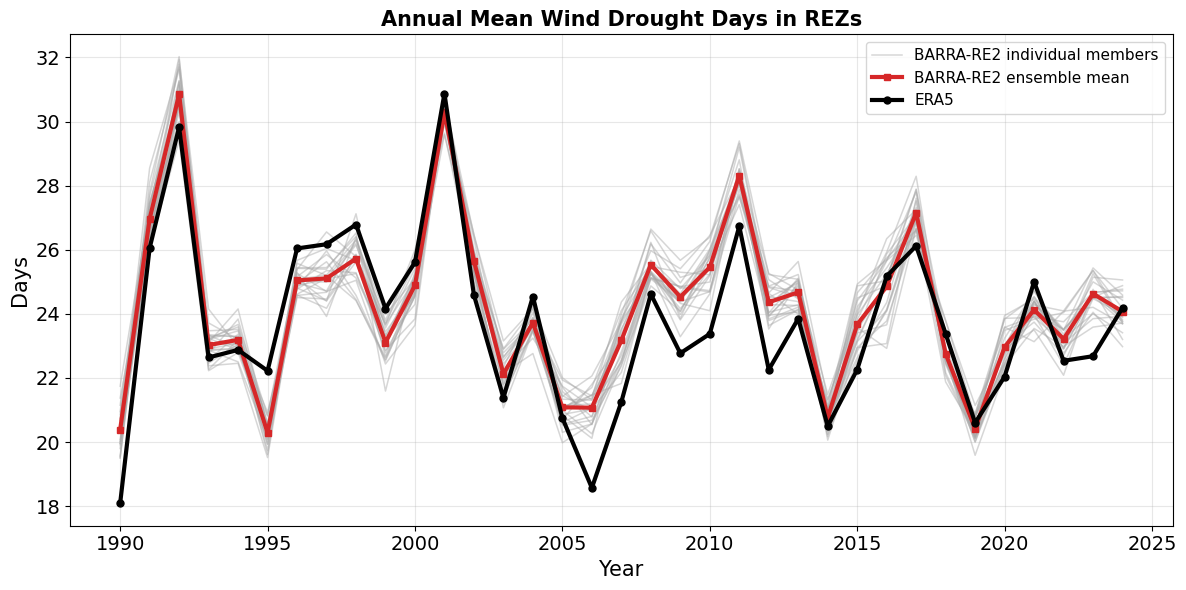

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_all_cells_ERA5_BARRA_ensemble_spaghetti.png


In [18]:
# =====================
# Plot 1: all REZ cells, zeros included
# This is the most direct REZ-wide ensemble comparison.
# =====================
png_all_cells = os.path.join(
    output_dir,
    "REZ_mean_annual_wind_drought_days_all_cells_ERA5_BARRA_ensemble_spaghetti.png"
)

plot_ensemble_spaghetti(
    metric_col="mean_annual_drought_days_all_rez_cells",
    ylabel="Days",
    title="Annual Mean Wind Drought Days in REZs",
    out_png=png_all_cells
)


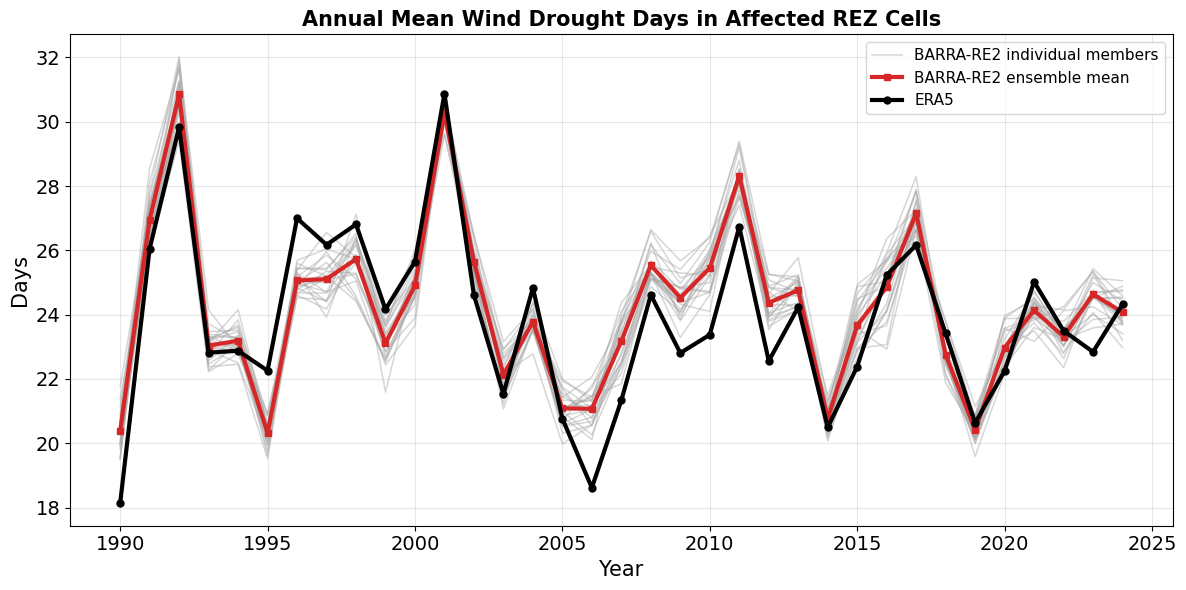

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_affected_cells_ERA5_BARRA_ensemble_spaghetti.png


In [19]:
# =====================
# Plot 2: affected REZ cells only
# This follows the affected-cell metric used in your earlier notebook.
# =====================
png_affected = os.path.join(
    output_dir,
    "REZ_mean_annual_wind_drought_days_affected_cells_ERA5_BARRA_ensemble_spaghetti.png"
)

plot_ensemble_spaghetti(
    metric_col="mean_annual_drought_days_affected_cells",
    ylabel="Days",
    title="Annual Mean Wind Drought Days in Affected REZ Cells",
    out_png=png_affected
)

scp ha2606@gadi.nci.org.au:/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_BARRA_ensemble_minus_ERA5_spaghetti.png  ~/Desktop/


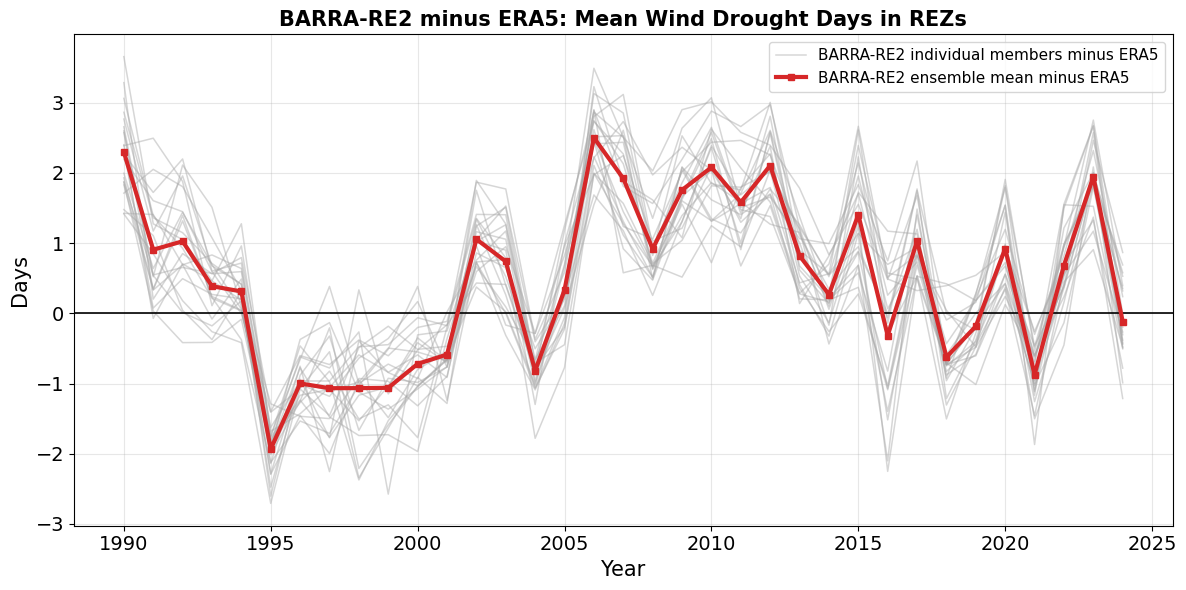

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_BARRA_ensemble_minus_ERA5_spaghetti.png


In [20]:
# =====================
# Plot 3: BARRA-RE2 minus ERA5 differences
# Grey lines = individual BARRA members minus ERA5
# Red line = BARRA ensemble mean minus ERA5
# =====================
plt.figure(figsize=(12, 6))

plt.axhline(0, color="black", lw=1.2, zorder=2)

first_member = True
for realization, sub in df_member_diff.groupby("realization"):
    plt.plot(
        sub["year"],
        sub["difference_mean_all_rez_cells_BARRA_minus_ERA5"],
        color="0.65",
        alpha=0.45,
        lw=1.1,
        zorder=1,
        label="BARRA-RE2 individual members minus ERA5" if first_member else None
    )
    first_member = False

plt.plot(
    compare_mean["year"],
    compare_mean["difference_mean_all_rez_cells_BARRA_mean_minus_ERA5"],
    color="tab:red",
    marker="s",
    markersize=5,
    lw=3.0,
    zorder=5,
    label="BARRA-RE2 ensemble mean minus ERA5"
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=15)
plt.ylabel("Days", fontsize=15)
plt.title(
    "BARRA-RE2 minus ERA5: Mean Wind Drought Days in REZs",
    fontsize=15,
    fontweight="bold"
)
plt.grid(alpha=0.3)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()

png_diff = os.path.join(
    output_dir,
    "REZ_mean_annual_wind_drought_days_BARRA_ensemble_minus_ERA5_spaghetti.png"
)
plt.savefig(png_diff, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", png_diff)


In [15]:
# =====================
# Summary statistics over the full period
# =====================
summary_rows = []

# ERA5 summary
summary_rows.append({
    "source": "ERA5",
    "realization": "ERA5",
    "mean_all_rez_cells_period_mean": df_era5["mean_annual_drought_days_all_rez_cells"].mean(),
    "mean_affected_rez_cells_period_mean": df_era5["mean_annual_drought_days_affected_cells"].mean(),
    "affected_cell_fraction_period_mean": df_era5["affected_cell_fraction"].mean(),
})

# BARRA member summaries
for realization, sub in df_barra_members.groupby("realization"):
    summary_rows.append({
        "source": "BARRA-RE2 member",
        "realization": realization,
        "mean_all_rez_cells_period_mean": sub["mean_annual_drought_days_all_rez_cells"].mean(),
        "mean_affected_rez_cells_period_mean": sub["mean_annual_drought_days_affected_cells"].mean(),
        "affected_cell_fraction_period_mean": sub["affected_cell_fraction"].mean(),
    })

# BARRA ensemble mean summary
summary_rows.append({
    "source": "BARRA-RE2 ensemble mean",
    "realization": "ensemble_mean",
    "mean_all_rez_cells_period_mean": df_barra_mean["mean_annual_drought_days_all_rez_cells"].mean(),
    "mean_affected_rez_cells_period_mean": df_barra_mean["mean_annual_drought_days_affected_cells"].mean(),
    "affected_cell_fraction_period_mean": df_barra_mean["affected_cell_fraction"].mean(),
})

summary = pd.DataFrame(summary_rows)
summary_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_ensemble_spaghetti_summary.csv")
summary.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
summary


Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_ensemble_spaghetti_summary.csv


,source,realization,mean_all_rez_cells_period_mean,mean_affected_rez_cells_period_mean,affected_cell_fraction_period_mean
0,ERA5,ERA5,23.727682,23.853099,0.994754
1,BARRA-RE2 member,000_0,24.358649,24.366432,0.999662
2,BARRA-RE2 member,000_1,24.628995,24.635278,0.999730
3,BARRA-RE2 member,001_0,23.848860,23.863966,0.999347
4,BARRA-RE2 member,001_1,24.356413,24.364907,0.999640
5,BARRA-RE2 member,002_0,23.954898,23.964200,0.999617
6,BARRA-RE2 member,002_1,24.282946,24.291475,0.999640
7,BARRA-RE2 member,003_0,23.864393,23.873881,0.999595
8,BARRA-RE2 member,003_1,24.329533,24.335331,0.999752
9,BARRA-RE2 member,004_0,23.966570,23.977792,0.999527


In [16]:
# =====================
# Final output list
# =====================
print("Main outputs saved in:", output_dir)
print("\nFigures:")
print(png_all_cells)
print(png_affected)
print(png_diff)

print("\nTables:")
print(all_csv)
print(barra_members_csv)
print(barra_mean_csv)
print(barra_spread_csv)
print(compare_mean_csv)
print(member_diff_csv)
print(summary_csv)


Main outputs saved in: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid

Figures:
/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_all_cells_ERA5_BARRA_ensemble_spaghetti.png
/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_affected_cells_ERA5_BARRA_ensemble_spaghetti.png
/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_mean_annual_wind_drought_days_BARRA_ensemble_minus_ERA5_spaghetti.png

Tables:
/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_ensemble_spaghetti_common_era5_grid/REZ_annual_wind_drought_days_ERA5_BARRA_members_and_BARRA_mean_long.csv
/scrat